jpeg圧縮を用いた敵対的防御について最も防御精度が高くなるjpeg_qualitiesの探索

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/projects/Medical/kaggledata'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# 出力ディレクトリ（画像・リザルト保存先）
OUTPUT_DIR = '/mnt/data1/gotou/kaggle/jpeg'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth


In [3]:
# --- 攻撃関数 ---
import torch.nn.functional as F

import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

# 前提: device, mean, std が外部で定義されている（投稿の定義をそのまま使えます）
# MEAN = np.array([...]); STD = np.array([...])
# mean = torch.tensor(MEAN).view(1,3,1,1).to(device)
# std  = torch.tensor(STD).view(1,3,1,1).to(device)

def denormalize(x, mean, std):
    # normalized -> pixel [0,1]
    return x * std + mean

def renormalize(x_pixel, mean, std):
    # pixel [0,1] -> normalized
    return (x_pixel - mean) / std

def fgsm_attack_improved(model, images, labels, epsilon_pixel, device,
                         mean_tensor=None, std_tensor=None, return_preds=True):
    """
    FGSM attack that respects per-channel normalization.
    Args:
      model: nn.Module, expects normalized inputs (same normalization used here)
      images: normalized tensor [B,C,H,W] (already normalized by mean/std)
      labels: tensor [B] (0/1) or shape [B,1]
      epsilon_pixel: float (e.g. 8/255) or tensor broadcastable to channels (pixel-scale)
      device: torch.device
      mean_tensor, std_tensor: tensors shaped [1,C,1,1] on device (if None, must be global)
      return_preds: if True, also return predicted labels on adversarial images
    Returns:
      adv_images: tensor [B,C,H,W] (normalized, detached)
      adv_preds (optional): LongTensor [B] predicted labels on adv_images (cpu)
    """
    # use provided mean/std or expect global variables `mean`/`std`
    if mean_tensor is None or std_tensor is None:
        # these should exist in your scope (as in your snippet)
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    # model output: assume logits for binary classification -> shape [B] or [B,1]
    outputs = model(images)
    if outputs.ndim > 1 and outputs.shape[1] == 1:
        outputs = outputs.squeeze(1)  # [B]
    # binary cross entropy with logits
    loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
    model.zero_grad()
    loss.backward()
    grad = images.grad.data  # gradient in normalized space

    # sign of gradient in normalized space
    grad_sign = grad.sign()

    # convert epsilon_pixel (pixel scale: 0..1) -> normalized-space epsilon per channel
    # support scalar epsilon_pixel or iterable per-channel
    if not torch.is_tensor(epsilon_pixel):
        eps_pixel_tensor = torch.tensor(epsilon_pixel, dtype=images.dtype, device=device)
    else:
        eps_pixel_tensor = epsilon_pixel.to(device).to(images.dtype)

    # make eps_norm shaped [1,C,1,1]
    if eps_pixel_tensor.ndim == 0:
        eps_norm = (eps_pixel_tensor / std_tensor_local).view(1, -1, 1, 1)
    elif eps_pixel_tensor.ndim == 1 and eps_pixel_tensor.numel() == std_tensor_local.shape[1]:
        eps_norm = (eps_pixel_tensor.view(1, -1, 1, 1) / std_tensor_local)
    else:
        # fallback: try to broadcast
        eps_norm = (eps_pixel_tensor / std_tensor_local)

    # create adversarial images in normalized space
    adv_images = images + eps_norm * grad_sign

    # clamp in pixel space
    adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
    adv_pixel = torch.clamp(adv_pixel, 0.0, 1.0)

    # back to normalized space
    adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    adv_images.requires_grad = False

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        # cleanup
        del grad, grad_sign, adv_out, adv_pixel, eps_norm, eps_pixel_tensor, loss
        torch.cuda.empty_cache()
        return adv_images, adv_preds

    # cleanup
    del grad, grad_sign, adv_pixel, eps_norm, eps_pixel_tensor, loss
    torch.cuda.empty_cache()
    return adv_images




In [4]:
# --- JPEG圧縮による防御関数 ---
import io
from PIL import Image

def jpeg_compression_defense(images, quality=75, mean_tensor=None, std_tensor=None):
    """
    JPEG圧縮による防御
    Args:
        images: normalized tensor [B,C,H,W] (already normalized by mean/std)
        quality: JPEG圧縮品質 (1-100, 低いほど圧縮が強い)
        mean_tensor, std_tensor: normalization parameters
    Returns:
        defended_images: tensor [B,C,H,W] (normalized)
    """
    if mean_tensor is None or std_tensor is None:
        mean_tensor = mean
        std_tensor = std
    
    batch_size = images.shape[0]
    defended_images = []
    
    for i in range(batch_size):
        # normalized -> pixel [0,1]
        img_pixel = denormalize(images[i:i+1], mean_tensor, std_tensor)
        # [0,1] -> [0,255]
        img_pil = transforms.ToPILImage()(img_pixel.squeeze(0).cpu())
        
        # JPEG圧縮・展開
        buffer = io.BytesIO()
        img_pil.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        img_jpeg = Image.open(buffer).convert('RGB')
        
        # PIL -> tensor [0,1]
        img_tensor = transforms.ToTensor()(img_jpeg).unsqueeze(0).to(images.device)
        # pixel [0,1] -> normalized
        img_normalized = renormalize(img_tensor, mean_tensor, std_tensor)
        
        defended_images.append(img_normalized)
    
    return torch.cat(defended_images, dim=0)

In [5]:
# --- 元画像で正解した100枚を抽出 ---
import matplotlib.pyplot as plt

model.eval()

correct_indices = []
correct_images = []
correct_labels = []
correct_img_ids = []

print("元画像で正解したサンプルを抽出中...")
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        if outputs.ndim > 1 and outputs.shape[1] == 1:
            outputs = outputs.squeeze(1)
        
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()
        
        # 正解したサンプルのインデックスを取得
        correct_mask = (preds == labels)
        correct_batch_indices = torch.where(correct_mask)[0]
        
        for idx in correct_batch_indices:
            correct_images.append(images[idx].cpu())
            correct_labels.append(labels[idx].cpu())
            
            if len(correct_images) >= 100:
                break

        if len(correct_images) >= 100:
            break

# 100枚に制限
correct_images = correct_images[:100]
correct_labels = correct_labels[:100]

correct_images_tensor = torch.stack(correct_images).to(device)
correct_labels_tensor = torch.stack(correct_labels).to(device)

print(f"抽出した正解サンプル数: {len(correct_images)}")
print(f"ラベルの内訳: {correct_labels_tensor.sum().item()}個が陽性, {len(correct_labels) - correct_labels_tensor.sum().item()}個が陰性")

元画像で正解したサンプルを抽出中...


  0%|          | 0/688 [00:00<?, ?it/s]

抽出した正解サンプル数: 100
ラベルの内訳: 52個が陽性, 48個が陰性


In [6]:
# --- FGSM攻撃を実行 ---
# 拡散モデルでの実験と同じepsilonを使用 (8/255)
epsilon = 8 / 255.0

print(f"FGSM攻撃を実行中 (epsilon={epsilon:.4f})...")
adv_images, adv_preds = fgsm_attack_improved(
    model=model,
    images=correct_images_tensor,
    labels=correct_labels_tensor,
    epsilon_pixel=epsilon,
    device=device,
    mean_tensor=mean,
    std_tensor=std,
    return_preds=True
)

# 敵対的画像の精度を計算
adv_accuracy = (adv_preds == correct_labels_tensor.cpu()).float().mean().item()
print(f"敵対的画像での精度: {adv_accuracy:.4f} ({int(adv_accuracy * 100)}/{len(correct_labels)})")
print(f"攻撃成功率: {1 - adv_accuracy:.4f}")

FGSM攻撃を実行中 (epsilon=0.0314)...
敵対的画像での精度: 0.5300 (52/100)
攻撃成功率: 0.4700


In [13]:
# --- JPEG圧縮による防御 ---
# 様々なJPEG品質で試す (品質が低いほど圧縮が強い)
jpeg_qualities = [8,9,10,11,12,13,14,15,16,17]

jpeg_results = {}

for quality in jpeg_qualities:
    print(f"\nJPEG品質={quality}で防御中...")
    defended_images = jpeg_compression_defense(
        adv_images,
        quality=quality,
        mean_tensor=mean,
        std_tensor=std
    )
    
    # 防御後の予測
    with torch.no_grad():
        defended_outputs = model(defended_images)
        if defended_outputs.ndim > 1 and defended_outputs.shape[1] == 1:
            defended_outputs = defended_outputs.squeeze(1)
        defended_probs = torch.sigmoid(defended_outputs)
        defended_preds = (defended_probs > 0.5).long().cpu()
    
    defended_accuracy = (defended_preds == correct_labels_tensor.cpu()).float().mean().item()
    jpeg_results[quality] = {
        'accuracy': defended_accuracy,
        'images': defended_images,
        'preds': defended_preds
    }
    
    print(f"JPEG品質={quality}: 防御後の精度 = {defended_accuracy:.4f} ({int(defended_accuracy * 100)}/{len(correct_labels)})")

# 結果のサマリー
print("\n" + "="*60)
print("結果サマリー (元画像で正解した100枚について)")
print("="*60)
print(f"元画像の精度:        100/100 (1.0000)")
print(f"敵対的画像の精度:    {int(adv_accuracy * 100)}/100 ({adv_accuracy:.4f})")
print("-"*60)
for quality in jpeg_qualities:
    acc = jpeg_results[quality]['accuracy']
    print(f"JPEG品質={quality:2d}での防御: {int(acc * 100):3d}/100 ({acc:.4f})")
print("="*60)


JPEG品質=8で防御中...
JPEG品質=8: 防御後の精度 = 0.7000 (69/100)

JPEG品質=9で防御中...
JPEG品質=8: 防御後の精度 = 0.7000 (69/100)

JPEG品質=9で防御中...
JPEG品質=9: 防御後の精度 = 0.6900 (68/100)

JPEG品質=10で防御中...
JPEG品質=9: 防御後の精度 = 0.6900 (68/100)

JPEG品質=10で防御中...
JPEG品質=10: 防御後の精度 = 0.7300 (73/100)

JPEG品質=11で防御中...
JPEG品質=10: 防御後の精度 = 0.7300 (73/100)

JPEG品質=11で防御中...
JPEG品質=11: 防御後の精度 = 0.7500 (75/100)

JPEG品質=12で防御中...
JPEG品質=11: 防御後の精度 = 0.7500 (75/100)

JPEG品質=12で防御中...
JPEG品質=12: 防御後の精度 = 0.7200 (72/100)

JPEG品質=13で防御中...
JPEG品質=12: 防御後の精度 = 0.7200 (72/100)

JPEG品質=13で防御中...
JPEG品質=13: 防御後の精度 = 0.7000 (69/100)

JPEG品質=14で防御中...
JPEG品質=13: 防御後の精度 = 0.7000 (69/100)

JPEG品質=14で防御中...
JPEG品質=14: 防御後の精度 = 0.7100 (70/100)

JPEG品質=15で防御中...
JPEG品質=14: 防御後の精度 = 0.7100 (70/100)

JPEG品質=15で防御中...
JPEG品質=15: 防御後の精度 = 0.7200 (72/100)

JPEG品質=16で防御中...
JPEG品質=15: 防御後の精度 = 0.7200 (72/100)

JPEG品質=16で防御中...
JPEG品質=16: 防御後の精度 = 0.6800 (68/100)

JPEG品質=17で防御中...
JPEG品質=16: 防御後の精度 = 0.6800 (68/100)

JPEG品質=17で防御中...
JPEG品質=17: 防御後の精度

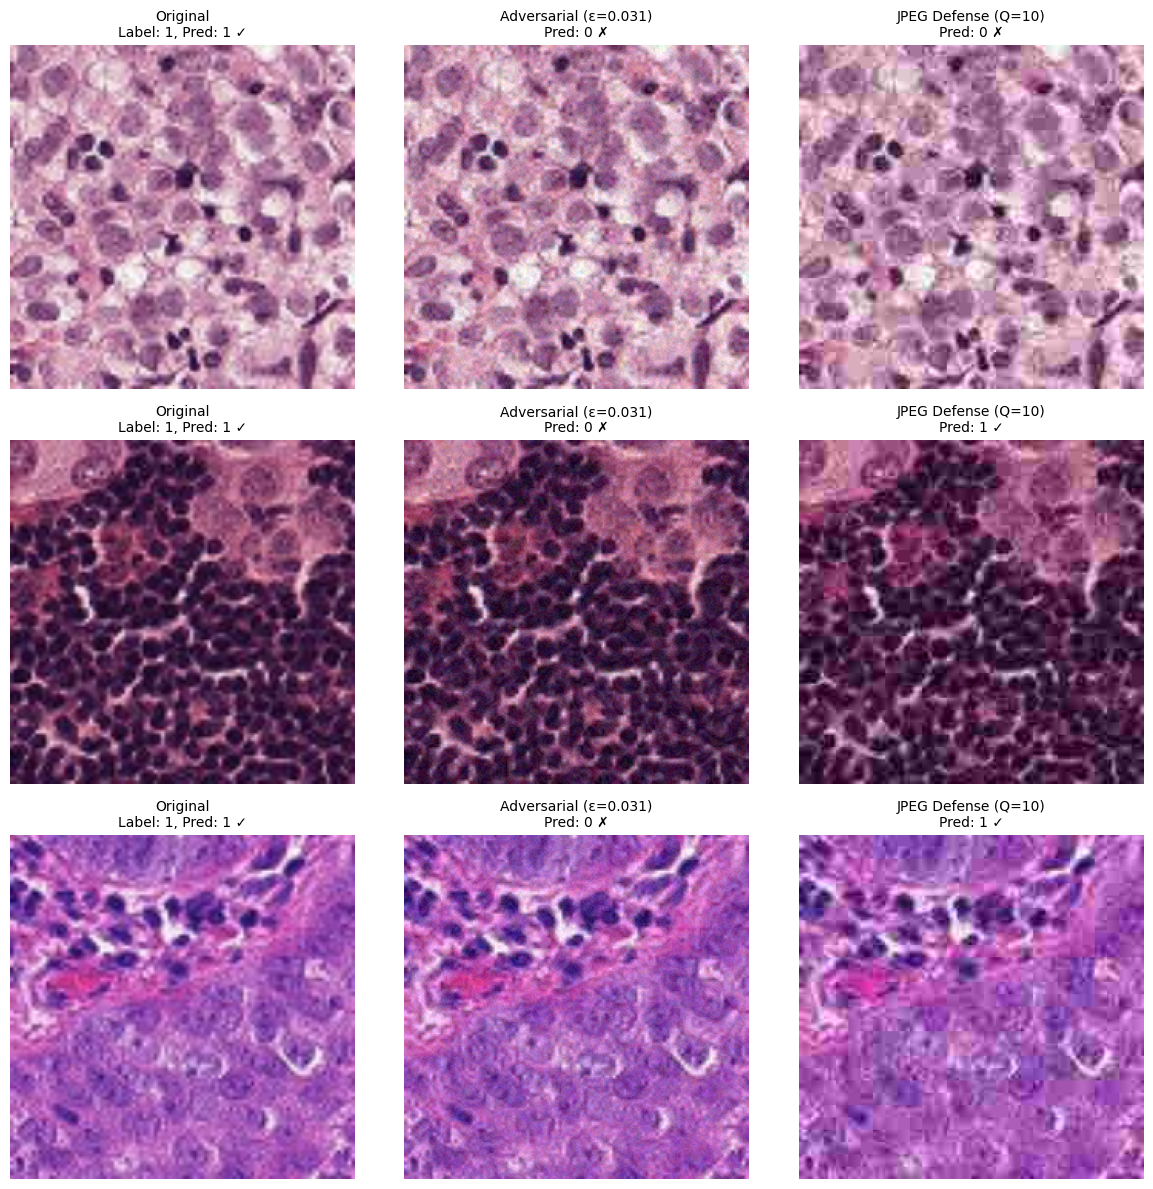


比較画像を保存しました: /mnt/data1/gotou/kaggle/jpeg/jpeg_defense_comparison.png


In [14]:
# --- 視覚的な比較: 複数のサンプルを表示 ---
# 表示するサンプル数
num_samples_to_show = 3

# JPEG品質10を代表として使用
representative_quality = 10
defended_images_repr = jpeg_results[representative_quality]['images']

fig, axes = plt.subplots(num_samples_to_show, 3, figsize=(12, num_samples_to_show * 4))

for i in range(num_samples_to_show):
    # 元画像
    orig_img = denormalize(correct_images_tensor[i:i+1], mean, std).squeeze(0).cpu()
    orig_img = torch.clamp(orig_img, 0, 1).permute(1, 2, 0).numpy()
    
    # 敵対的画像
    adv_img = denormalize(adv_images[i:i+1], mean, std).squeeze(0).cpu()
    adv_img = torch.clamp(adv_img, 0, 1).permute(1, 2, 0).numpy()
    
    # 防御後の画像
    def_img = denormalize(defended_images_repr[i:i+1], mean, std).squeeze(0).cpu()
    def_img = torch.clamp(def_img, 0, 1).permute(1, 2, 0).numpy()
    
    # 元画像の予測 (正解している)
    orig_pred = correct_labels_tensor[i].item()
    orig_label = correct_labels_tensor[i].item()
    
    # 敵対的画像の予測
    adv_pred = adv_preds[i].item()
    
    # 防御後の予測
    def_pred = jpeg_results[representative_quality]['preds'][i].item()
    
    # 表示
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f'Original\nLabel: {orig_label}, Pred: {orig_pred} ✓', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(adv_img)
    marker = '✓' if adv_pred == orig_label else '✗'
    axes[i, 1].set_title(f'Adversarial (ε={epsilon:.3f})\nPred: {adv_pred} {marker}', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(def_img)
    marker = '✓' if def_pred == orig_label else '✗'
    axes[i, 2].set_title(f'JPEG Defense (Q={representative_quality})\nPred: {def_pred} {marker}', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'jpeg_defense_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n比較画像を保存しました: {os.path.join(OUTPUT_DIR, 'jpeg_defense_comparison.png')}")

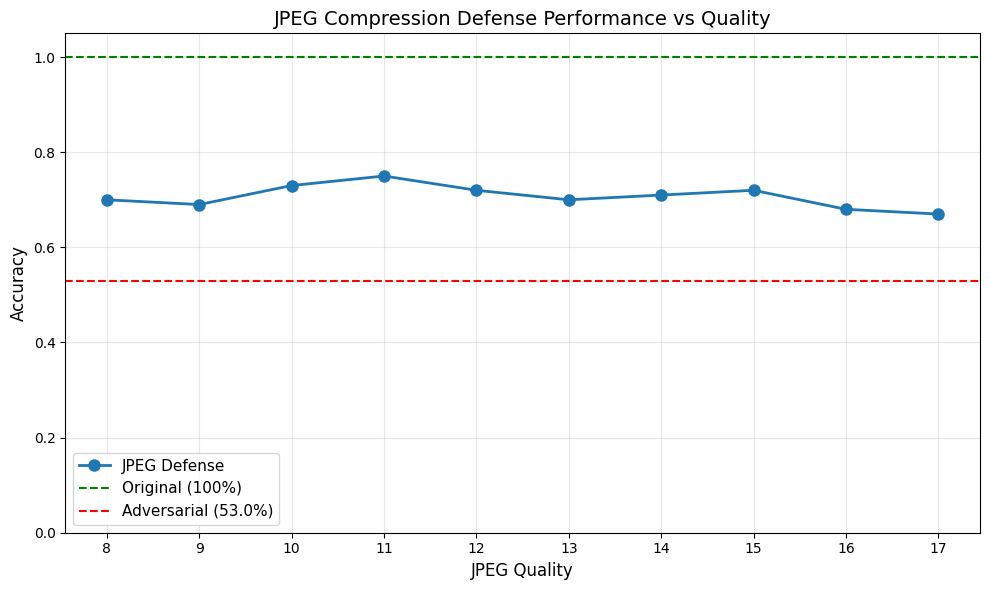


精度グラフを保存しました: /mnt/data1/gotou/kaggle/jpeg/jpeg_defense_accuracy.png


In [15]:
# --- JPEG品質ごとの防御性能をグラフ化 ---
qualities = list(jpeg_results.keys())
accuracies = [jpeg_results[q]['accuracy'] for q in qualities]

plt.figure(figsize=(10, 6))
plt.plot(qualities, accuracies, 'o-', linewidth=2, markersize=8, label='JPEG Defense')
plt.axhline(y=1.0, color='g', linestyle='--', linewidth=1.5, label='Original (100%)')
plt.axhline(y=adv_accuracy, color='r', linestyle='--', linewidth=1.5, label=f'Adversarial ({adv_accuracy:.1%})')

plt.xlabel('JPEG Quality', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('JPEG Compression Defense Performance vs Quality', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim([0, 1.05])
plt.xticks(qualities)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'jpeg_defense_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n精度グラフを保存しました: {os.path.join(OUTPUT_DIR, 'jpeg_defense_accuracy.png')}")

In [16]:
# --- 詳細な結果をCSVに保存 ---
results_data = {
    'Sample_ID': list(range(100)),
    'True_Label': correct_labels_tensor.cpu().numpy(),
    'Original_Pred': [1] * 100,  # すべて正解
    'Adversarial_Pred': adv_preds.numpy(),
}

# 各JPEG品質での予測結果を追加
for quality in jpeg_qualities:
    results_data[f'JPEG_Q{quality}_Pred'] = jpeg_results[quality]['preds'].numpy()

results_df = pd.DataFrame(results_data)

# 各サンプルでの攻撃成功/防御成功を判定
results_df['Attack_Success'] = (results_df['Adversarial_Pred'] != results_df['True_Label']).astype(int)

for quality in jpeg_qualities:
    # 攻撃が成功したサンプルの中で、防御が成功したかどうか
    results_df[f'JPEG_Q{quality}_Defense_Success'] = (
        (results_df['Attack_Success'] == 1) & 
        (results_df[f'JPEG_Q{quality}_Pred'] == results_df['True_Label'])
    ).astype(int)

csv_path = os.path.join(OUTPUT_DIR, 'jpeg_defense_results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\n詳細な結果をCSVに保存しました: {csv_path}")

# サマリー統計（防御後の分類精度）
print("\n" + "="*60)
print("JPEG圧縮防御後の分類精度")
print("="*60)
print(f"元画像の精度:      100/100 (1.0000)")
print(f"敵対的画像の精度:   {int(adv_accuracy * 100):2d}/100 ({adv_accuracy:.4f})")
print("-"*60)
for quality in jpeg_qualities:
    defended_correct = (results_df[f'JPEG_Q{quality}_Pred'] == results_df['True_Label']).sum()
    defended_accuracy = defended_correct / 100
    print(f"JPEG品質={quality:3d}:  {defended_correct:2d}/100 ({defended_accuracy:.4f})")
print("="*60)


詳細な結果をCSVに保存しました: /mnt/data1/gotou/kaggle/jpeg/jpeg_defense_results.csv

JPEG圧縮防御後の分類精度
元画像の精度:      100/100 (1.0000)
敵対的画像の精度:   52/100 (0.5300)
------------------------------------------------------------
JPEG品質=  8:  70/100 (0.7000)
JPEG品質=  9:  69/100 (0.6900)
JPEG品質= 10:  73/100 (0.7300)
JPEG品質= 11:  75/100 (0.7500)
JPEG品質= 12:  72/100 (0.7200)
JPEG品質= 13:  70/100 (0.7000)
JPEG品質= 14:  71/100 (0.7100)
JPEG品質= 15:  72/100 (0.7200)
JPEG品質= 16:  68/100 (0.6800)
JPEG品質= 17:  67/100 (0.6700)
